## How to use this notebook

- **Single-run cells**: The first few code cells run one simulation each for the sequential, standard, and parallel processes and drive the Gantt / single-permit views.
- **Multi-run cells**: The later cells that call `run_multiple_simulations` run many simulations per process and feed the aggregate statistics and comparison plots.
- **Workflow**: Run the single-run block first (to keep Gantt charts tied to one run), then run the multi-run block to update the aggregate visualizations.

In [1]:
from run_simulation import run_simulation, print_statistics, run_multiple_simulations
from visualize_permits import (
    visualize_all,
    plot_median_total_time_by_process,
    plot_gantt_one_random_permit_segment,
)
import matplotlib.pyplot as plt
import numpy as np

# Common parameters for both analyses
NUM_PERMITS = 2000
RANDOM_SEED = 42

In [2]:
# Run all three simulations
# Edit these values to test additional assumptions.
SIMULATION_PARAMS = {
    "simulation_duration": None,
    "ai_review": "none",
    "permit_mix": "balanced",
    "pre_application_distribution": "lognormal_180",
    "review_duration_families": None,      # e.g. {"planning": "lognormal", "public_works": "normal", "fire": "triangular"}
    "review_duration_multipliers": None,   # e.g. {"planning": 1.2, "public_works": 1.0, "fire": 0.9, "special_zoning": 1.0, "agency_referral": 1.0}
    "planning_staff_count": 20,
    "planning_caseload_per_staff": 7,
    "public_works_staff_count": 30,
    "public_works_caseload_per_staff": 7,
    "fire_staff_count": 10,
    "fire_caseload_per_staff": 7,
}

common_run_kwargs = {
    "num_permits": NUM_PERMITS,
    "random_seed": RANDOM_SEED,
    **SIMULATION_PARAMS,
}

print(f"Running sequential simulation with {NUM_PERMITS} permits...")
sim_sequential = run_simulation(
    **common_run_kwargs,
    sequential="sequential",
)

print(f"\nRunning standard simulation with {NUM_PERMITS} permits...")
sim_standard = run_simulation(
    **common_run_kwargs,
    sequential="standard",
)

print(f"\nRunning parallel simulation with {NUM_PERMITS} permits...")
sim_parallel = run_simulation(
    **common_run_kwargs,
    sequential="parallel",
)

Running sequential simulation with 2000 permits...

Running standard simulation with 2000 permits...

Running parallel simulation with 2000 permits...


In [3]:
# Print statistics for each process
print("=== SEQUENTIAL PROCESS ===")
stats_sequential = sim_sequential.get_statistics()
print_statistics(stats_sequential)

print("=== STANDARD PROCESS ===")
stats_standard = sim_standard.get_statistics()
print_statistics(stats_standard)

print("\n=== PARALLEL PROCESS ===")
stats_parallel = sim_parallel.get_statistics()
print_statistics(stats_parallel)


=== SEQUENTIAL PROCESS ===

SIMULATION STATISTICS

Total Completed Permits: 2000
Total In Progress: 0

--------------------------------------------------------------------------------
SEGMENT DISTRIBUTION
--------------------------------------------------------------------------------
  CUSTOM_LIKE                   :  805 (40.25%)
  CUSTOM_NON_LIKE               :  197 ( 9.85%)
  PRE_APPROVED_LIKE             :  390 (19.50%)
  PRE_APPROVED_NON_LIKE         :  103 ( 5.15%)
  SELF_CERT_LIKE                :  403 (20.15%)
  SELF_CERT_NON_LIKE            :  102 ( 5.10%)

--------------------------------------------------------------------------------
OVERALL PROCESSING TIME STATISTICS
--------------------------------------------------------------------------------
  Mean:     418.79 days
  Median:   397.05 days
  Std Dev:  137.88 days
  Min:      114.62 days
  Max:     1353.21 days

--------------------------------------------------------------------------------
PROCESSING TIME BY SEGMENT

In [4]:
# Run multiple simulations for each process configuration to see aggregate behavior
N_RUNS = 100

# Reuse the exact same parameters configured in the single-run cell.
SIMULATION_DURATION = SIMULATION_PARAMS.get("simulation_duration", None)
MULTI_RUN_PARAMS = {
    k: v for k, v in SIMULATION_PARAMS.items() if k != "simulation_duration"
}

scenario_params_list = [
    {"name": "Sequential", **MULTI_RUN_PARAMS, "sequential": "sequential"},
    {"name": "Standard", **MULTI_RUN_PARAMS, "sequential": "standard"},
    {"name": "Parallel", **MULTI_RUN_PARAMS, "sequential": "parallel"},
]

multi_run_kwargs = {
    "n_runs": N_RUNS,
    "num_permits": NUM_PERMITS,
    "simulation_duration": SIMULATION_DURATION,
    "base_seed": RANDOM_SEED,
    "scenario_params_list": scenario_params_list,
    "collect_permits": True,
}

# Progress bar for each replicate × scenario (requires `pip install tqdm`)
SHOW_MULTI_RUN_PROGRESS = True
if SHOW_MULTI_RUN_PROGRESS:
    multi_run_kwargs["show_progress"] = True
    multi_run_kwargs["progress_desc"] = "Multi-run (Seq / Std / Par)"

from simulation_plot_helpers import permits_partitioned_by_run

multi_results = run_multiple_simulations(**multi_run_kwargs)

runs_by_process = {
    "Sequential": permits_partitioned_by_run(multi_results, "Sequential"),
    "Standard": permits_partitioned_by_run(multi_results, "Standard"),
    "Parallel": permits_partitioned_by_run(multi_results, "Parallel"),
}

all_sequential_permits = [p for run in runs_by_process["Sequential"] for p in run]
all_standard_permits = [p for run in runs_by_process["Standard"] for p in run]
all_parallel_permits = [p for run in runs_by_process["Parallel"] for p in run]


def _print_summary(name: str, permits: list) -> None:
    if not permits:
        print(f"{name}: no completed permits across runs")
        return
    total_times = np.array(
        [
            p.ready_for_construction - p.created_at
            for p in permits
            if getattr(p, "ready_for_construction", None) is not None
        ]
    )
    if total_times.size == 0:
        print(f"{name}: no permits with ready_for_construction timestamps")
        return

    print(
        f"{name}: n={len(total_times)}, mean={total_times.mean():.2f}, "
        f"median={np.median(total_times):.2f}"
    )


print(f"Ran {N_RUNS} runs per process (sequential / standard / parallel). Aggregate total-time stats:")
_print_summary("Sequential", all_sequential_permits)
_print_summary("Standard", all_standard_permits)
_print_summary("Parallel", all_parallel_permits)


Multi-run (Seq / Std / Par):   0%|          | 0/300 [00:00<?, ?run/s]

Ran 100 runs per process (sequential / standard / parallel). Aggregate total-time stats:
Sequential: n=200000, mean=421.28, median=400.94
Standard: n=200000, mean=300.71, median=276.29
Parallel: n=200000, mean=246.50, median=219.75


**Total time disaster → construction by segment (days)**

,series,n,n_runs,q1,median,q3,whisker_low,whisker_high
0,Sequential | Custom like,80405,100,344.708383,414.555148,502.499310,115.731732,739.053003
1,Standard | Custom like,80405,100,227.473796,289.148497,371.444223,48.786789,587.378918
2,Parallel | Custom like,80405,100,182.319787,240.990812,321.519573,53.533999,530.231940
3,Sequential | Pre-approved like,39539,100,265.062511,317.319221,376.095373,100.729462,542.302987
4,Standard | Pre-approved like,39539,100,156.204176,195.208332,244.258239,44.632275,376.282774
5,Parallel | Pre-approved like,39539,100,124.687916,150.586599,193.215147,28.211559,296.002953
6,Sequential | Self-certified like,40260,100,338.385986,408.859895,495.040044,105.674069,729.961165
7,Standard | Self-certified like,40260,100,224.913524,286.501178,368.498875,63.272366,583.659045
8,Parallel | Self-certified like,40260,100,181.230237,239.863304,320.067431,48.506867,527.817567
9,Sequential | Custom non-like,19954,100,411.389398,490.248810,583.555283,181.392483,841.631226


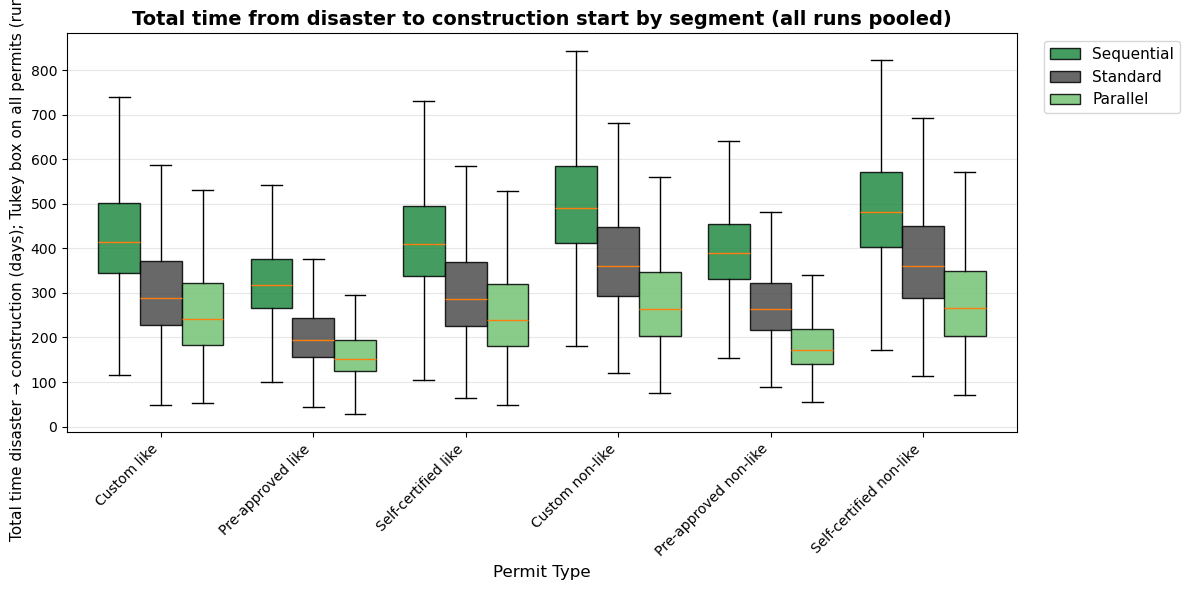

In [5]:
# Within-run medians by segment; boxplots summarize run-to-run variation
fig, ax = plot_median_total_time_by_process(runs_by_process)
if fig is not None:
    plt.show()


SEQUENTIAL process – Segment 4 permit


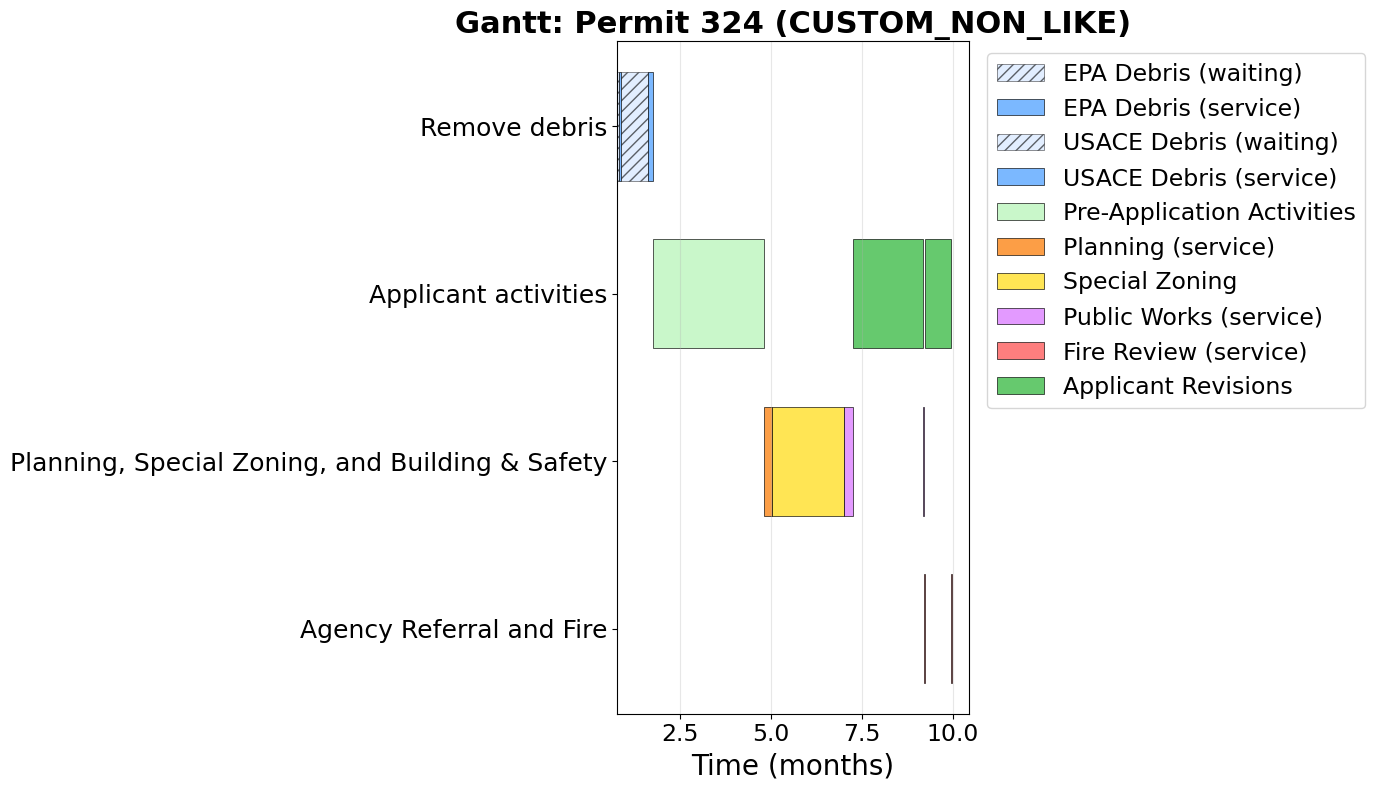


STANDARD process – Segment 4 permit


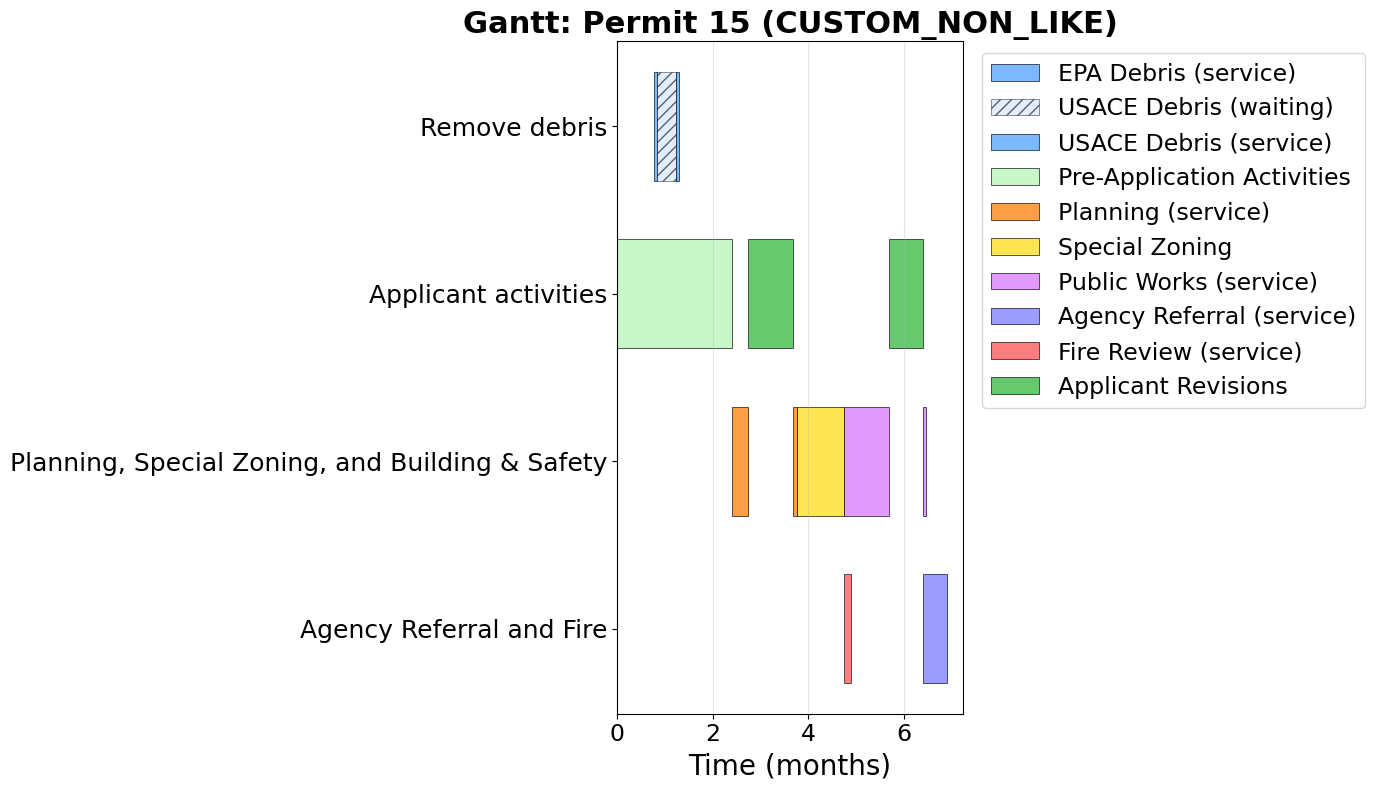


PARALLEL process – Segment 4 permit


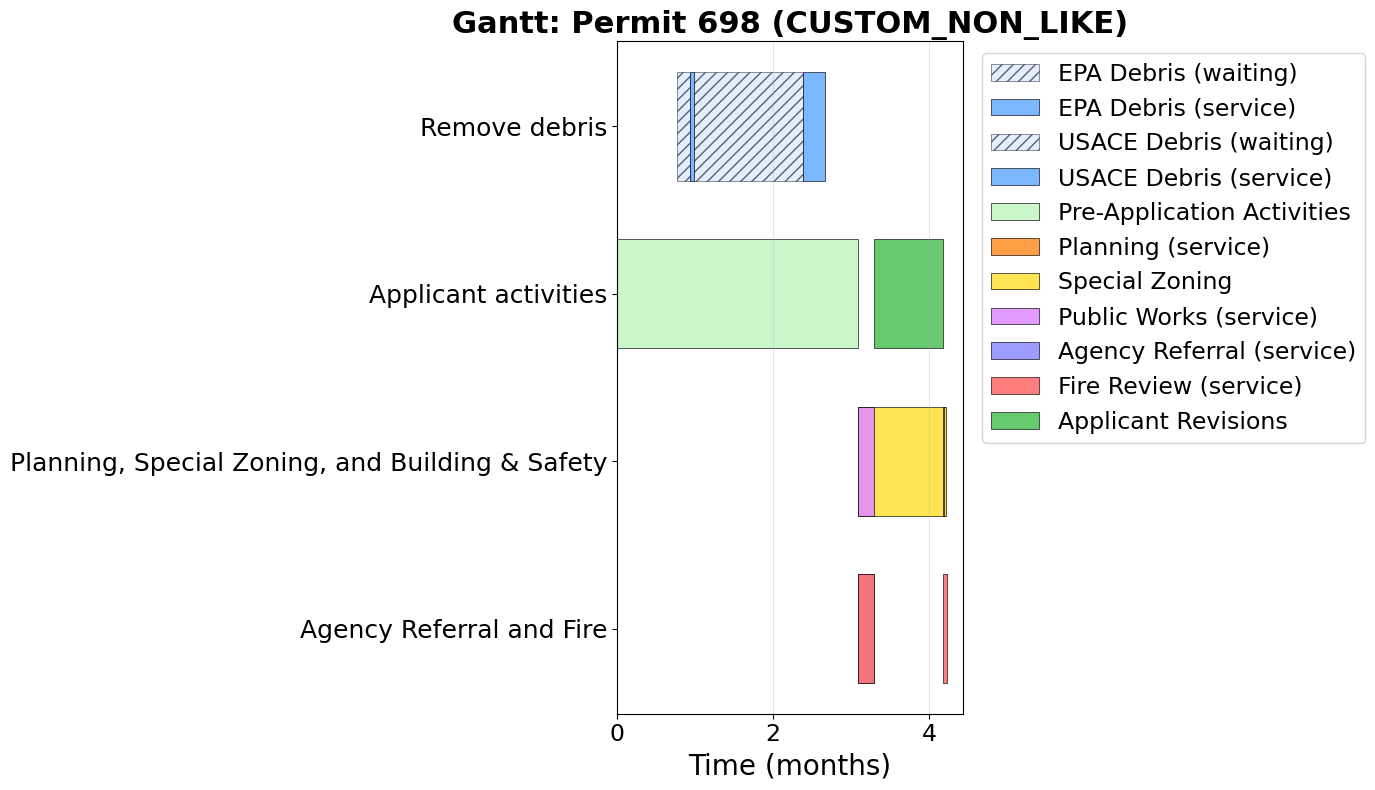

In [6]:
# Gantt charts for one random Segment 4 permit under each process
print("SEQUENTIAL process – Segment 4 permit")
fig1, ax1 = plot_gantt_one_random_permit_segment(
    sim_sequential.completed_permits,
    segment_value=4,
    random_seed=123,
    figsize=(14, 8),
)
if fig1 is not None:
    plt.show()

print("\nSTANDARD process – Segment 4 permit")
fig2, ax2 = plot_gantt_one_random_permit_segment(
    sim_standard.completed_permits,
    segment_value=4,
    random_seed=123,
    figsize=(14, 8),
)
if fig2 is not None:
    plt.show()

print("\nPARALLEL process – Segment 4 permit")
fig3, ax3 = plot_gantt_one_random_permit_segment(
    sim_parallel.completed_permits,
    segment_value=4,
    random_seed=123,
    figsize=(14, 8),
)
if fig3 is not None:
    plt.show()


Creating visualizations for SEQUENTIAL process...
Creating visualizations for 2000 permits...
  Creating total time by segment chart (box plot)...


**Total time disaster → construction by segment (years)**

,series,n,mean,std,min,q1,median,q3,max
0,Custom like,805,1.172366,0.374683,0.432480,0.931361,1.104289,1.354785,2.695588
1,Pre-approved like,390,0.876353,0.226609,0.314023,0.720458,0.866084,1.004426,1.577604
2,Self-certified like,403,1.181869,0.344509,0.431083,0.943942,1.133018,1.376466,2.815588
3,Custom non-like,197,1.387796,0.357844,0.689111,1.123081,1.317305,1.616734,2.679052
4,Pre-approved non-like,103,1.102051,0.288329,0.568660,0.901977,1.071648,1.251455,2.089908
5,Self-certified non-like,102,1.431305,0.463225,0.722217,1.131623,1.403780,1.650330,3.707431


  Creating waiting vs service by step chart...


**Average waiting vs service by process step (mean per permit)**

,series,n,mean,std,min,q1,median,q3,max
0,EPA Debris — waiting,2000,8.245207,5.424457,0.000000,3.410349,8.290633,12.883166,17.801245
1,EPA Debris — service,2000,1.522093,1.251758,0.003488,0.631919,1.183161,2.050847,12.621292
2,USACE Debris — waiting,2000,56.211435,30.729915,0.000000,30.609147,55.826476,83.097970,106.598155
3,USACE Debris — service,2000,1.980426,1.415638,0.023064,0.924456,1.695786,2.689104,11.634987
4,Pre-Application Activities — waiting,2000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,Pre-Application Activities — service,2000,178.237209,114.350429,20.051493,98.296096,149.456246,226.369060,845.213142
6,Planning — waiting,2000,0.000140,0.006281,0.000000,0.000000,0.000000,0.000000,0.280889
7,Planning — service,2000,6.755240,2.971056,0.751812,4.516097,6.221752,8.468400,19.958941
8,Special Zoning — waiting,402,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,Special Zoning — service,402,59.774742,64.069391,6.856662,27.828714,46.220966,76.796063,1034.860036


Waiting / service by step (days); mean ± σ (pooled permit-level):
  EPA Debris (EPA Debris): waiting mean=8.25, σ=5.42; service mean=1.52, σ=1.25
  USACE Debris (USACE Debris): waiting mean=56.21, σ=30.73; service mean=1.98, σ=1.42
  Pre-Application Activities (Pre-Application Activities): waiting mean=0.00, σ=0.00; service mean=178.24, σ=114.35
  Planning (Planning): waiting mean=0.00, σ=0.01; service mean=6.76, σ=2.97
  Special Zoning (Special Zoning): waiting mean=0.00, σ=0.00; service mean=59.77, σ=64.07
  Public Works (Public Works): waiting mean=0.00, σ=0.00; service mean=5.49, σ=4.47
  Agency Referral (Agency Referral): waiting mean=0.00, σ=0.00; service mean=39.42, σ=27.11
  Fire Review (Fire Review): waiting mean=0.00, σ=0.00; service mean=3.54, σ=3.51
  Applicant Revisions (Applicant Revisions): waiting mean=0.00, σ=0.00; service mean=119.58, σ=50.57


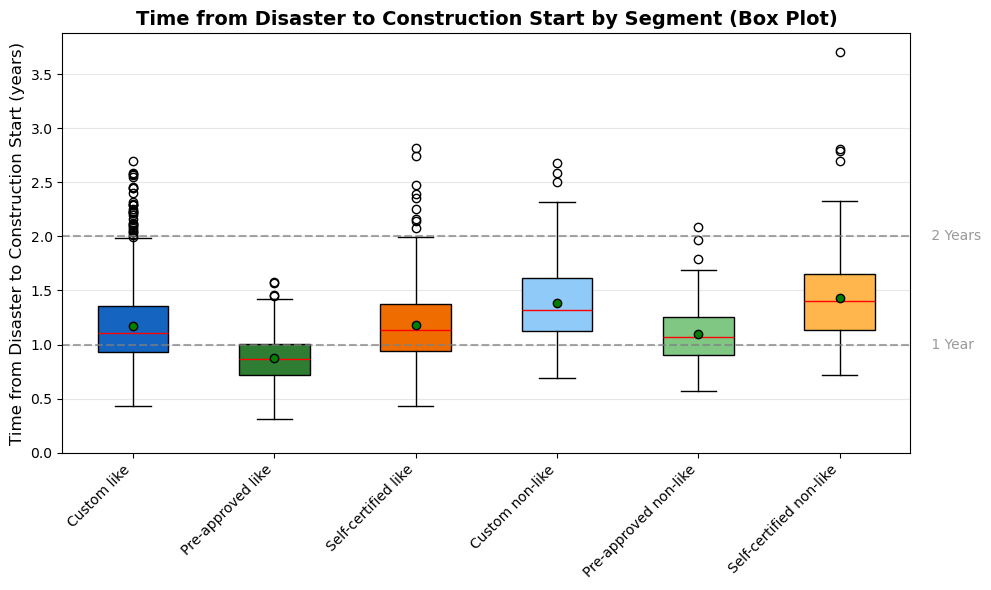

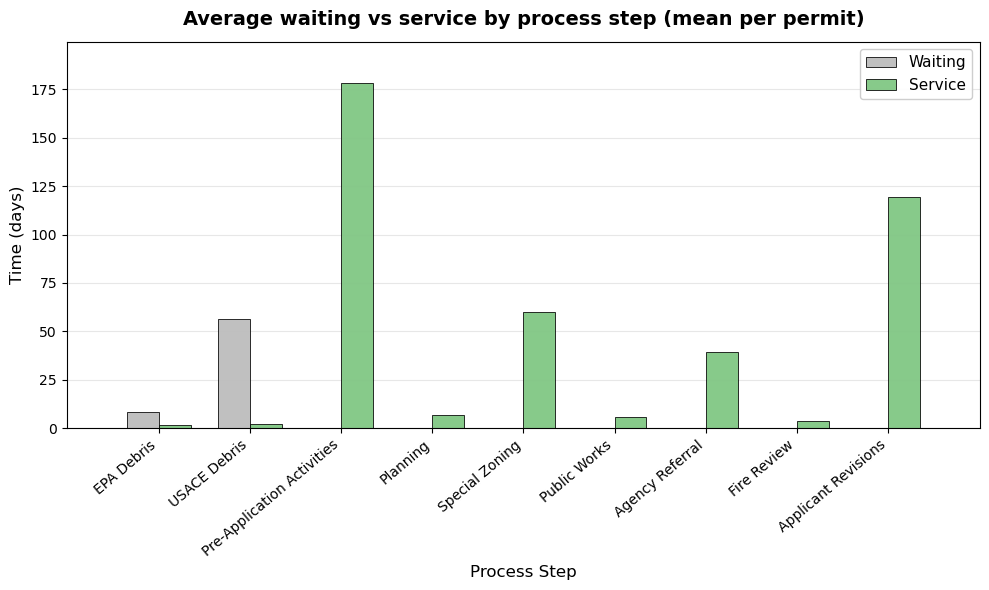

Visualizations complete!


In [7]:
# Full visualization set for each process (mirrors prior single-process notebooks)
print("Creating visualizations for SEQUENTIAL process...")
visualize_all(sim_sequential.completed_permits, save_prefix=None, show=True)



Creating visualizations for STANDARD process...
Creating visualizations for 2000 permits...
  Creating total time by segment chart (box plot)...


**Total time disaster → construction by segment (years)**

,series,n,mean,std,min,q1,median,q3,max
0,Custom like,805,0.874799,0.359244,0.263527,0.632756,0.800105,1.034104,3.055769
1,Pre-approved like,390,0.566527,0.186132,0.235507,0.435628,0.542840,0.656251,1.356143
2,Self-certified like,403,0.862905,0.332641,0.260163,0.635768,0.792545,1.037654,2.305379
3,Custom non-like,197,1.068113,0.360398,0.537669,0.805697,1.020146,1.228718,2.835563
4,Pre-approved non-like,103,0.783691,0.259999,0.348971,0.632717,0.740750,0.892999,2.336324
5,Self-certified non-like,102,1.060214,0.371952,0.426460,0.779901,0.990926,1.255474,2.422973


  Creating waiting vs service by step chart...


**Average waiting vs service by process step (mean per permit)**

,series,n,mean,std,min,q1,median,q3,max
0,EPA Debris — waiting,2000,8.229226,5.423420,0.000000,3.442442,8.341409,12.960284,17.664826
1,EPA Debris — service,2000,1.511011,1.243399,0.005280,0.620609,1.195990,2.044840,12.621292
2,USACE Debris — waiting,2000,56.603439,30.930241,0.000000,29.692883,57.746116,82.638872,109.491793
3,USACE Debris — service,2000,2.029859,1.421176,0.043293,0.995218,1.698464,2.738739,8.876682
4,Pre-Application Activities — waiting,2000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,Pre-Application Activities — service,2000,185.554378,117.768112,19.134518,102.670200,158.974685,233.810213,977.798740
6,Planning — waiting,2000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,Planning — service,2000,6.851186,2.987398,0.759684,4.699202,6.353137,8.549597,19.597667
8,Special Zoning — waiting,402,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,Special Zoning — service,402,58.989414,46.622172,7.972121,28.809341,47.121354,71.310861,341.508398


Waiting / service by step (days); mean ± σ (pooled permit-level):
  EPA Debris (EPA Debris): waiting mean=8.23, σ=5.42; service mean=1.51, σ=1.24
  USACE Debris (USACE Debris): waiting mean=56.60, σ=30.93; service mean=2.03, σ=1.42
  Pre-Application Activities (Pre-Application Activities): waiting mean=0.00, σ=0.00; service mean=185.55, σ=117.77
  Planning (Planning): waiting mean=0.00, σ=0.00; service mean=6.85, σ=2.99
  Special Zoning (Special Zoning): waiting mean=0.00, σ=0.00; service mean=58.99, σ=46.62
  Public Works (Public Works): waiting mean=0.00, σ=0.00; service mean=5.52, σ=4.58
  Agency Referral (Agency Referral): waiting mean=0.00, σ=0.00; service mean=39.33, σ=30.50
  Fire Review (Fire Review): waiting mean=0.00, σ=0.00; service mean=3.66, σ=3.76
  Applicant Revisions (Applicant Revisions): waiting mean=0.00, σ=0.00; service mean=94.72, σ=40.63


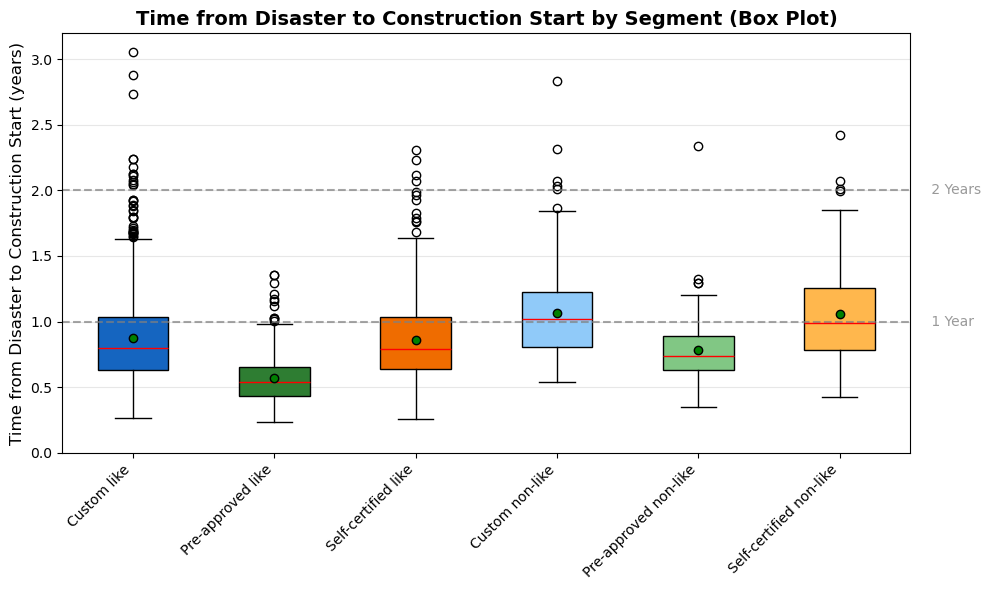

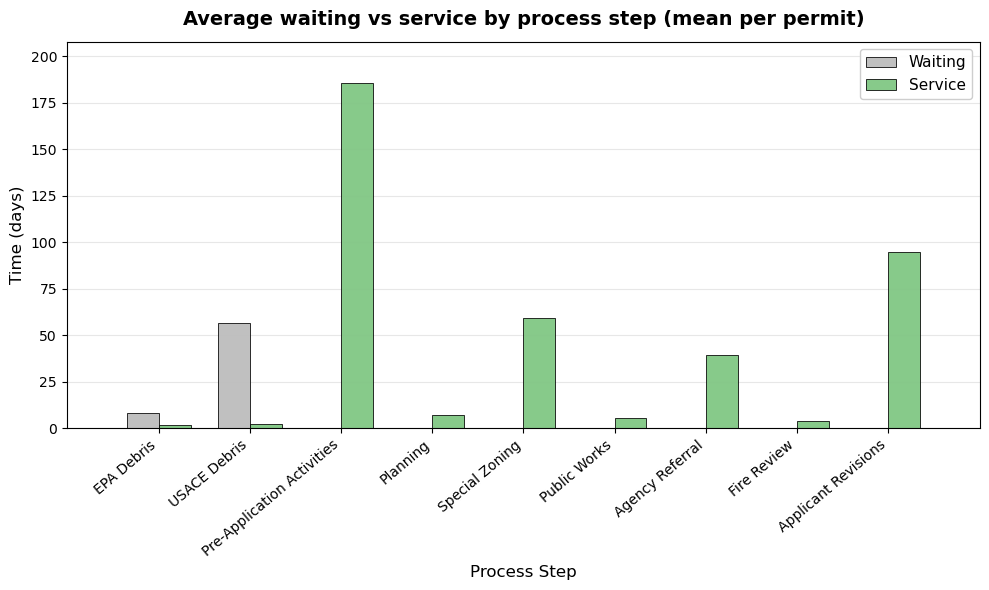

Visualizations complete!


In [8]:
print("\nCreating visualizations for STANDARD process...")
visualize_all(sim_standard.completed_permits, save_prefix=None, show=True)


Creating visualizations for PARALLEL process...
Creating visualizations for 2000 permits...
  Creating total time by segment chart (box plot)...


**Total time disaster → construction by segment (years)**

,series,n,mean,std,min,q1,median,q3,max
0,Custom like,805,0.742959,0.347397,0.248078,0.510551,0.660097,0.874733,2.842663
1,Pre-approved like,390,0.458319,0.165565,0.177827,0.347224,0.414869,0.539894,1.274941
2,Self-certified like,403,0.741164,0.329062,0.155099,0.521812,0.677105,0.891557,2.247565
3,Custom non-like,197,0.808207,0.335555,0.258003,0.562247,0.751099,0.953901,2.191888
4,Pre-approved non-like,103,0.543293,0.212173,0.273485,0.413450,0.507110,0.635569,1.968678
5,Self-certified non-like,102,0.820879,0.360774,0.301072,0.585967,0.755154,0.962550,2.085022


  Creating waiting vs service by step chart...


**Average waiting vs service by process step (mean per permit)**

,series,n,mean,std,min,q1,median,q3,max
0,EPA Debris — waiting,2000,8.236809,5.420465,0.000000,3.394769,8.312159,12.983644,17.577229
1,EPA Debris — service,2000,1.497027,1.223810,0.005280,0.624676,1.177608,2.034860,12.621292
2,USACE Debris — waiting,2000,58.352266,31.279406,0.000000,32.184304,58.996966,85.193908,108.947214
3,USACE Debris — service,2000,2.005671,1.423502,0.039782,0.977294,1.678401,2.687225,11.634987
4,Pre-Application Activities — waiting,2000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,Pre-Application Activities — service,2000,185.554378,117.768112,19.134518,102.670200,158.974685,233.810213,977.798740
6,Planning — waiting,2000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,Planning — service,2000,6.856049,3.013068,1.115948,4.686130,6.240374,8.421076,21.685384
8,Special Zoning — waiting,402,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,Special Zoning — service,402,58.165990,44.941110,4.747390,27.407139,42.952796,76.530295,262.269804


Waiting / service by step (days); mean ± σ (pooled permit-level):
  EPA Debris (EPA Debris): waiting mean=8.24, σ=5.42; service mean=1.50, σ=1.22
  USACE Debris (USACE Debris): waiting mean=58.35, σ=31.28; service mean=2.01, σ=1.42
  Pre-Application Activities (Pre-Application Activities): waiting mean=0.00, σ=0.00; service mean=185.55, σ=117.77
  Planning (Planning): waiting mean=0.00, σ=0.00; service mean=6.86, σ=3.01
  Special Zoning (Special Zoning): waiting mean=0.00, σ=0.00; service mean=58.17, σ=44.94
  Public Works (Public Works): waiting mean=0.00, σ=0.00; service mean=5.62, σ=4.69
  Agency Referral (Agency Referral): waiting mean=0.00, σ=0.00; service mean=42.69, σ=46.81
  Fire Review (Fire Review): waiting mean=0.00, σ=0.00; service mean=3.76, σ=3.77
  Applicant Revisions (Applicant Revisions): waiting mean=0.00, σ=0.00; service mean=54.46, σ=30.46


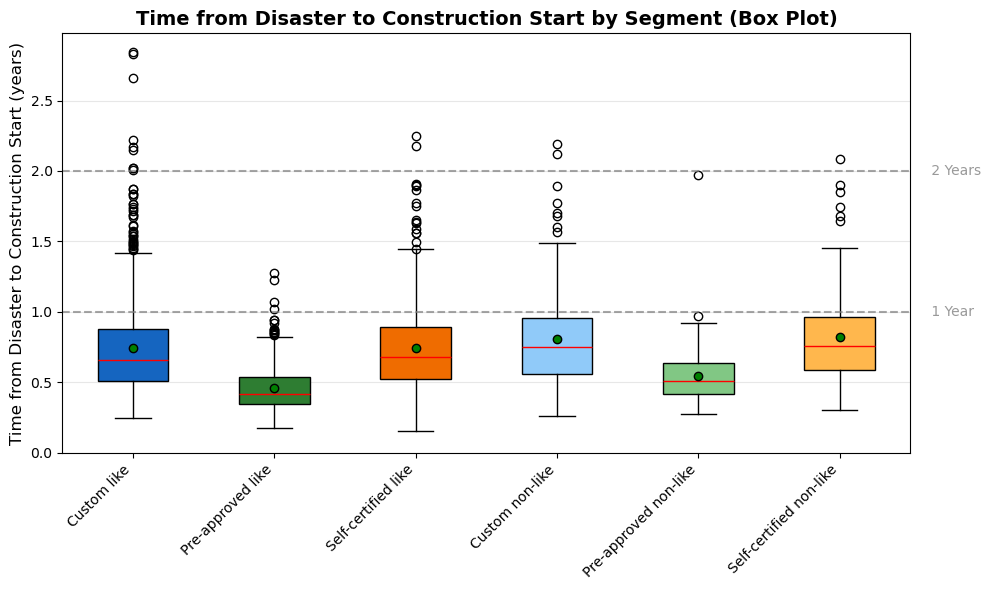

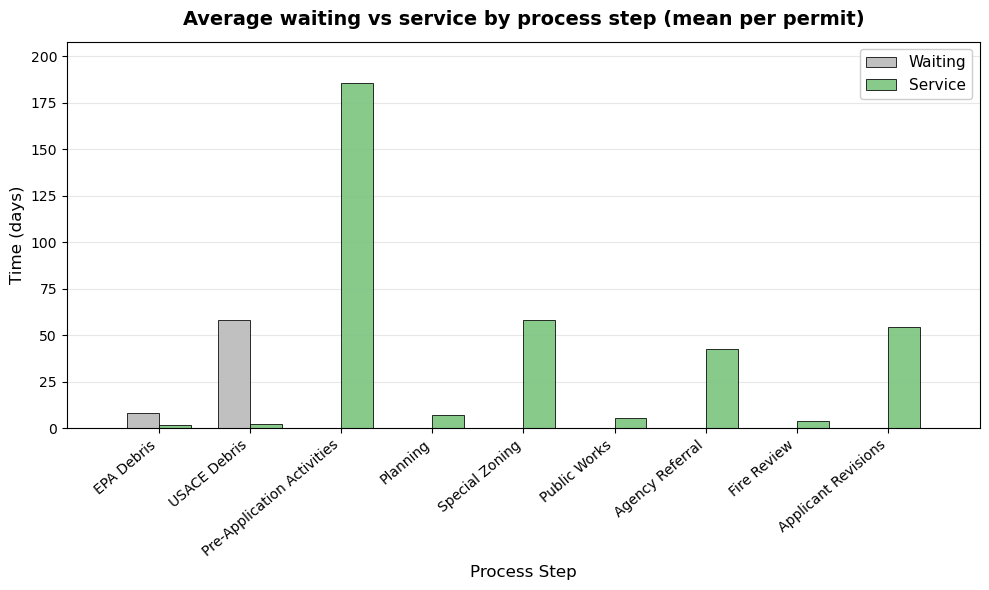

Visualizations complete!


In [9]:
print("\nCreating visualizations for PARALLEL process...")
visualize_all(sim_parallel.completed_permits, save_prefix=None, show=True)

In [10]:
# Diagnostic: like-for-like step-level timeline comparison by process
import pandas as pd
from permit_simulation import Segment

LIKE_SEGMENTS = {
    Segment.PRE_APPROVED_LIKE,
    Segment.CUSTOM_LIKE,
    Segment.SELF_CERT_LIKE,
}


def _like_step_summary(permits: list) -> dict:
    like_only = [p for p in permits if p.segment in LIKE_SEGMENTS and p.ready_for_construction is not None]
    if not like_only:
        return {"n": 0}

    def _mean(values):
        vals = [v for v in values if v is not None]
        return float(np.mean(vals)) if vals else np.nan

    return {
        "n": len(like_only),
        "total_time": _mean([p.ready_for_construction - p.created_at for p in like_only]),
        "application_to_construction": _mean([
            (p.ready_for_construction - p.planning_request)
            for p in like_only
            if p.planning_request is not None
        ]),
        "planning_wait": _mean([p.planning_total_waiting for p in like_only]),
        "planning_service": _mean([p.planning_initial_service + p.planning_recheck_service for p in like_only]),
        "public_works_wait": _mean([p.public_works_total_waiting for p in like_only]),
        "public_works_service": _mean([p.public_works_initial_service + p.public_works_recheck_service for p in like_only]),
        "fire_wait": _mean([p.fire_review_total_waiting for p in like_only]),
        "fire_service": _mean([p.fire_initial_service + p.fire_recheck_service for p in like_only]),
        "special_zoning_service": _mean([
            (p.zoning_end - p.zoning_start)
            if p.zoning_start is not None and p.zoning_end is not None
            else 0.0
            for p in like_only
        ]),
        "agency_referral_total": _mean([
            (p.agency_referral_end - p.agency_referral_request)
            if p.agency_referral_request is not None and p.agency_referral_end is not None
            else 0.0
            for p in like_only
        ]),
        "applicant_revisions": _mean([p.applicant_revisions_total_time for p in like_only]),
        "planning_rechecks": _mean([p.planning_rechecks for p in like_only]),
        "public_works_rechecks": _mean([p.public_works_rechecks for p in like_only]),
        "fire_rechecks": _mean([p.fire_rechecks for p in like_only]),
    }


process_like = {
    "Sequential": _like_step_summary(all_sequential_permits),
    "Standard": _like_step_summary(all_standard_permits),
    "Parallel": _like_step_summary(all_parallel_permits),
}

comparison_df = pd.DataFrame(process_like).T
comparison_df = comparison_df[[
    "n",
    "total_time",
    "application_to_construction",
    "planning_wait",
    "planning_service",
    "public_works_wait",
    "public_works_service",
    "fire_wait",
    "fire_service",
    "special_zoning_service",
    "agency_referral_total",
    "applicant_revisions",
    "planning_rechecks",
    "public_works_rechecks",
    "fire_rechecks",
]].round(2)

print("Like-for-like diagnostics by process (mean days unless noted):")
display(comparison_df)

if "Standard" in comparison_df.index:
    delta_vs_standard = (comparison_df - comparison_df.loc["Standard"]).round(2)
    print("\nDelta vs Standard (mean days unless noted):")
    display(delta_vs_standard)


Like-for-like diagnostics by process (mean days unless noted):


,n,total_time,application_to_construction,planning_wait,planning_service,public_works_wait,public_works_service,fire_wait,fire_service,special_zoning_service,agency_referral_total,applicant_revisions,planning_rechecks,public_works_rechecks,fire_rechecks
Sequential,160204.0,406.61,133.74,0.0,6.00,0.0,5.51,0.0,3.66,0.0,0.0,118.56,1.0,1.0,0.63
Standard,160204.0,286.58,104.55,0.0,5.99,0.0,5.51,0.0,3.69,0.0,0.0,94.03,1.0,1.0,0.63
Parallel,160204.0,241.96,59.93,0.0,6.00,0.0,5.51,0.0,3.68,0.0,0.0,54.62,1.0,1.0,0.63



Delta vs Standard (mean days unless noted):


,n,total_time,application_to_construction,planning_wait,planning_service,public_works_wait,public_works_service,fire_wait,fire_service,special_zoning_service,agency_referral_total,applicant_revisions,planning_rechecks,public_works_rechecks,fire_rechecks
Sequential,0.0,120.03,29.19,0.0,0.01,0.0,0.0,0.0,-0.03,0.0,0.0,24.53,0.0,0.0,0.0
Standard,0.0,0.00,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0
Parallel,0.0,-44.62,-44.62,0.0,0.01,0.0,0.0,0.0,-0.01,0.0,0.0,-39.41,0.0,0.0,0.0


### Median total time by segment — full scenario grid

Runs **sequential / standard / parallel** for every combination of **staffing** (low / medium / high), **permit volume** (2,000 vs 6,500), and **pre-application distribution** fixed at `lognormal_180`. Figures are saved under `results/median_total_time_by_process/` with basenames defined by `FIG_BASENAME_TEMPLATE` in the cell below (default: `application_to_ready_by_segment_staff-…`).

Lower `N_RUNS_GRID` for a quick test; increase for publication-quality medians.

**Progress:** install `tqdm` (`pip install tqdm`, listed in `requirements.txt`). Toggle `SHOW_PROGRESS_OUTER` / `SHOW_PROGRESS_RUNS` for the scenario vs per-batch progress bars. In cell 4 (multi-run), use `SHOW_MULTI_RUN_PROGRESS`.


In [11]:
import csv
import json
import statistics
from itertools import product
from pathlib import Path

import matplotlib.pyplot as plt
import importlib
import visualize_permits
importlib.reload(visualize_permits)
from run_simulation import run_multiple_simulations
from simulation_plot_helpers import permits_partitioned_by_run
from visualize_permits import plot_median_total_time_by_process

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = None  # type: ignore

# Progress: outer bar = scenario figures; inner bar = each batch (N_RUNS × 3 processes)
SHOW_PROGRESS_OUTER = True
SHOW_PROGRESS_RUNS = True

# Matches policy / volume comparison notebooks (caseload 7 per stage)
STAFFING_SCENARIOS = {
    "low": {
        "planning_staff_count": 2,
        "public_works_staff_count": 3,
        "fire_staff_count": 1,
    },
    "medium": {
        "planning_staff_count": 8,
        "public_works_staff_count": 12,
        "fire_staff_count": 4,
    },
    "high": {
        "planning_staff_count": 20,
        "public_works_staff_count": 30,
        "fire_staff_count": 10,
    },
}

PRE_APPLICATION_DISTS = ["lognormal_180"]
PERMIT_COUNTS = [2000, 6500]

# Monte Carlo runs **per process** (Sequential, Standard, Parallel) for each scenario cell
N_RUNS_GRID = 100
BASE_SEED_GRID = 42

SHARED_KNOBS = {
    "simulation_duration": None,
    "ai_review": "none",
    "permit_mix": "balanced",
    "review_duration_families": None,
    "review_duration_multipliers": None,
    "planning_caseload_per_staff": 7,
    "public_works_caseload_per_staff": 7,
    "fire_caseload_per_staff": 7,
}

results_dir = Path("results") / "median_total_time_by_process"
results_dir.mkdir(parents=True, exist_ok=True)

# Saved PNG basename pattern, figure title, and y-axis label — edit for thesis wording.
FIG_BASENAME_TEMPLATE = (
    "application_to_ready_by_segment_staff-{staff}_permits-{perm}_pre-{pre}.png"
)
FIG_TITLE_TEMPLATE = (
    "Process Configuration Comparison Across Segments "
    "({staff} Staffing Scenario, {perm:,} Permits)"
)
FIG_YLABEL = "Permitting time (days)"

n_scenarios = len(STAFFING_SCENARIOS) * len(PERMIT_COUNTS) * len(PRE_APPLICATION_DISTS)
total_sims = n_scenarios * N_RUNS_GRID * 3
print(
    f"Generating {n_scenarios} scenario figures; up to {total_sims} total simulation runs."
)

use_inner_progress = SHOW_PROGRESS_RUNS and tqdm is not None
if SHOW_PROGRESS_RUNS and tqdm is None:
    print("Note: install tqdm (`pip install tqdm`) for per-run progress bars.")


def permit_to_row(permit):
    if isinstance(permit, dict):
        base_row = permit
    elif hasattr(permit, "to_dict"):
        base_row = permit.to_dict()  # type: ignore[attr-defined]
    elif hasattr(permit, "__dict__"):
        base_row = vars(permit)
    else:
        base_row = {"permit_repr": repr(permit)}

    clean_row = {}
    for k, v in base_row.items():
        if isinstance(v, (str, int, float, bool)) or v is None:
            clean_row[k] = v
        else:
            clean_row[k] = json.dumps(v, sort_keys=True, default=str)
    return clean_row


def get_application_to_ready_days(permit):
    ready_time = getattr(permit, "ready_for_construction", None)
    app_time = getattr(permit, "planning_request", None)
    if ready_time is None or app_time is None:
        return None
    return float(ready_time - app_time)


all_output_rows = []
scenario_summary_rows = []

scenario_grid = list(
    product(STAFFING_SCENARIOS.items(), PERMIT_COUNTS, PRE_APPLICATION_DISTS)
)
scenario_iter = (
    tqdm(scenario_grid, desc="Scenario figures", unit="fig")
    if SHOW_PROGRESS_OUTER and tqdm is not None
    else scenario_grid
)

for (staffing_name, staff_counts), num_perm, pre_dist in scenario_iter:
    scenario_params_list = []
    base = dict(SHARED_KNOBS)
    base.update(staff_counts)
    base["pre_application_distribution"] = pre_dist

    for proc_name, seq in [
        ("Sequential", "sequential"),
        ("Standard", "standard"),
        ("Parallel", "parallel"),
    ]:
        scenario_params_list.append(
            {
                "name": proc_name,
                "sequential": seq,
                "num_permits": num_perm,
                **base,
            }
        )

    multi_results = run_multiple_simulations(
        n_runs=N_RUNS_GRID,
        num_permits=num_perm,
        simulation_duration=None,
        base_seed=BASE_SEED_GRID,
        scenario_params_list=scenario_params_list,
        collect_permits=True,
        show_progress=use_inner_progress,
        progress_desc=f"{staffing_name} | n={num_perm} | {pre_dist}",
        progress_leave=False,
    )

    for res in multi_results:
        plist = res.get("permits", [])
        scenario = res["scenario"]

        total_times = []
        for permit in plist:
            total_time = get_application_to_ready_days(permit)
            if total_time is not None:
                total_times.append(total_time)

            permit_row = permit_to_row(permit)
            all_output_rows.append(
                {
                    "staffing_scenario": staffing_name,
                    "permit_count": num_perm,
                    "pre_application_distribution": pre_dist,
                    "process": scenario,
                    "application_to_ready_days": total_time,
                    **permit_row,
                }
            )

        scenario_summary_rows.append(
            {
                "staffing_scenario": staffing_name,
                "permit_count": num_perm,
                "pre_application_distribution": pre_dist,
                "process": scenario,
                "n_completed_permits": len(total_times),
                "application_to_ready_median_days": (
                    statistics.median(total_times) if total_times else None
                ),
                "application_to_ready_mean_days": (
                    statistics.mean(total_times) if total_times else None
                ),
                "application_to_ready_std_days": (
                    statistics.stdev(total_times) if len(total_times) > 1 else 0.0
                ),
            }
        )

    runs_by_process = {
        "Sequential": permits_partitioned_by_run(multi_results, "Sequential"),
        "Standard": permits_partitioned_by_run(multi_results, "Standard"),
        "Parallel": permits_partitioned_by_run(multi_results, "Parallel"),
    }

    safe_pre = pre_dist.replace("lognormal_", "log")
    outfile = results_dir / FIG_BASENAME_TEMPLATE.format(
        staff=staffing_name, perm=num_perm, pre=safe_pre
    )
    title = FIG_TITLE_TEMPLATE.format(
        staff=staffing_name.title(), perm=num_perm
    )
    fig, ax = plot_median_total_time_by_process(
        runs_by_process,
        figsize=(12, 6),
        title=title,
        application_to_ready=True,
        ylabel=FIG_YLABEL,
    )
    if fig is not None:
        fig.savefig(outfile, dpi=150, bbox_inches="tight")
        plt.close(fig)
        print(f"Saved {outfile}")
    else:
        print(f"Skipped (no data): {title}")

csv_outfile = results_dir / "median_total_time_by_process_outputs.csv"
if all_output_rows:
    fieldnames = sorted({k for row in all_output_rows for k in row})
    with csv_outfile.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(all_output_rows)
    print(f"Saved {csv_outfile} ({len(all_output_rows):,} rows)")
else:
    print("No output rows collected; CSV not written.")

summary_outfile = results_dir / "median_total_time_by_process_scenario_summary.csv"
if scenario_summary_rows:
    summary_fieldnames = [
        "staffing_scenario",
        "permit_count",
        "pre_application_distribution",
        "process",
        "n_completed_permits",
        "application_to_ready_median_days",
        "application_to_ready_mean_days",
        "application_to_ready_std_days",
    ]
    with summary_outfile.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=summary_fieldnames)
        writer.writeheader()
        writer.writerows(scenario_summary_rows)
    print(f"Saved {summary_outfile} ({len(scenario_summary_rows):,} rows)")
else:
    print("No scenario summary rows collected; summary CSV not written.")

print("Done.")


Generating 6 scenario figures; up to 1800 total simulation runs.


Scenario figures:   0%|          | 0/6 [00:00<?, ?fig/s]

low | n=2000 | lognormal_180:   0%|          | 0/300 [00:00<?, ?run/s]

**Process Configuration Comparison Across Segments (Low Staffing Scenario, 2,000 Permits)**

,series,n,n_runs,q1,median,q3,whisker_low,whisker_high
0,Sequential | Custom like,80405,100,210.591852,572.905942,734.304756,9.106971,1098.210330
1,Standard | Custom like,80405,100,202.569061,575.705440,732.152343,7.084979,1026.275701
2,Parallel | Custom like,80405,100,440.522102,589.840385,679.402303,82.222699,949.667301
3,Sequential | Pre-approved like,39539,100,158.708045,348.335679,545.514890,2.070810,1017.072853
4,Standard | Pre-approved like,39539,100,134.741572,315.433103,504.643732,6.019385,974.833869
5,Parallel | Pre-approved like,39539,100,128.732658,295.944447,465.496022,7.560932,916.236834
6,Sequential | Self-certified like,40260,100,204.275105,568.402964,727.551006,3.240689,1052.682862
7,Standard | Self-certified like,40260,100,204.788454,576.967305,729.459558,3.159023,1067.356655
8,Parallel | Self-certified like,40260,100,445.708465,591.942136,679.821050,94.575697,923.935024
9,Sequential | Custom non-like,19954,100,303.888890,646.389427,801.060086,59.871944,1445.006542


...

Saved results/median_total_time_by_process/application_to_ready_by_segment_staff-high_permits-2000_pre-log180.png


high | n=6500 | lognormal_180:   0%|          | 0/300 [00:00<?, ?run/s]

**Process Configuration Comparison Across Segments (High Staffing Scenario, 6,500 Permits)**

,series,n,n_runs,q1,median,q3,whisker_low,whisker_high
0,Sequential | Custom like,260397,100,107.108370,142.812014,184.298676,4.563387,300.083979
1,Standard | Custom like,260397,100,102.555320,147.952296,247.540045,4.060063,464.995610
2,Parallel | Custom like,260397,100,55.089385,90.636820,178.999718,2.202788,364.667297
3,Sequential | Pre-approved like,129285,100,100.289219,136.304420,179.043230,2.363505,297.172816
4,Standard | Pre-approved like,129285,100,125.267853,189.742415,277.970186,3.296261,507.014907
5,Parallel | Pre-approved like,129285,100,95.305817,156.094095,219.880503,1.747164,406.346673
6,Sequential | Self-certified like,130578,100,100.382967,136.016627,177.145768,2.537427,292.284900
7,Standard | Self-certified like,130578,100,99.097078,145.193184,245.941402,1.701416,465.826387
8,Parallel | Self-certified like,130578,100,53.284272,88.926554,176.227891,1.342996,360.292259
9,Sequential | Custom non-like,64691,100,169.438392,211.911950,263.423667,29.468530,404.298495


Saved results/median_total_time_by_process/application_to_ready_by_segment_staff-high_permits-6500_pre-log180.png
Saved results/median_total_time_by_process/median_total_time_by_process_outputs.csv (7,650,000 rows)
Saved results/median_total_time_by_process/median_total_time_by_process_scenario_summary.csv (1,800 rows)
Done.
